# spaCy NER — BC5CDR vs BC5CDR + GENIA (Negative Sampling)

**Experiment**: Does adding GENIA sentences (with all labels set to O) help spaCy learn better NER on BC5CDR?

- **Model 1**: spaCy trained on BC5CDR only
- **Model 2**: spaCy trained on BC5CDR + GENIA (all GENIA labels → O)

Both models are evaluated on the same BC5CDR test set for fair comparison.

In [1]:
!pip install spacy scikit-learn matplotlib --quiet
!python -m spacy download en_core_web_sm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 59.3 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 1. Config

In [2]:
BC5CDR_DIR = '/kaggle/input/datasets/prajnagaur/bc5cdr-ntu'
GENIA_DIR  = '/kaggle/input/datasets/prajnagaur/genia-ntu'

SAVE_DIR_BASE   = 'models/spacy/bc5cdr_only'
SAVE_DIR_GENIA  = 'models/spacy/bc5cdr_genia'

MAX_EPOCHS = 20
PATIENCE   = 5

print('Config ready')

Config ready


## 2. Imports

In [3]:
import json, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import spacy
from spacy.tokens import DocBin
from spacy.training import Example

print('Imports done')

Imports done


In [4]:
import os
for root, dirs, files in os.walk('/kaggle'):
    for f in files:
        if 'train.jsonl' in f:
            print(os.path.join(root, f))
import os
for root, dirs, files in os.walk('/kaggle'):
    for f in files:
        if '.jsonl' in f:
            print(os.path.join(root, f))

/kaggle/input/datasets/prajnagaur/bc5cdr-ntu/train.jsonl
/kaggle/input/datasets/prajnagaur/genia-ntu/train.jsonl
/kaggle/input/datasets/prajnagaur/bc5cdr-ntu/test.jsonl
/kaggle/input/datasets/prajnagaur/bc5cdr-ntu/validation.jsonl
/kaggle/input/datasets/prajnagaur/bc5cdr-ntu/train.jsonl
/kaggle/input/datasets/prajnagaur/genia-ntu/test.jsonl
/kaggle/input/datasets/prajnagaur/genia-ntu/validation_unlabeled.jsonl
/kaggle/input/datasets/prajnagaur/genia-ntu/validation.jsonl
/kaggle/input/datasets/prajnagaur/genia-ntu/test_unlabeled.jsonl
/kaggle/input/datasets/prajnagaur/genia-ntu/train.jsonl
/kaggle/input/datasets/prajnagaur/genia-ntu/train_unlabeled.jsonl


In [5]:
import os
for root, dirs, files in os.walk('/kaggle'):
    for f in files:
        if '.jsonl' in f:
            print(os.path.join(root, f))

/kaggle/input/datasets/prajnagaur/bc5cdr-ntu/test.jsonl
/kaggle/input/datasets/prajnagaur/bc5cdr-ntu/validation.jsonl
/kaggle/input/datasets/prajnagaur/bc5cdr-ntu/train.jsonl
/kaggle/input/datasets/prajnagaur/genia-ntu/test.jsonl
/kaggle/input/datasets/prajnagaur/genia-ntu/validation_unlabeled.jsonl
/kaggle/input/datasets/prajnagaur/genia-ntu/validation.jsonl
/kaggle/input/datasets/prajnagaur/genia-ntu/test_unlabeled.jsonl
/kaggle/input/datasets/prajnagaur/genia-ntu/train.jsonl
/kaggle/input/datasets/prajnagaur/genia-ntu/train_unlabeled.jsonl


## 3. Data loading helpers

In [6]:
def load_jsonl(path):
    records = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

def extract_tokens_labels(records):
    sentences, labels = [], []
    for rec in records:
        if 'tokens' in rec and 'ner_tags' in rec:
            toks, labs = rec['tokens'], rec['ner_tags']
        elif 'tokens' in rec and 'labels' in rec:
            toks, labs = rec['tokens'], rec['labels']
        elif 'words' in rec and 'tags' in rec:
            toks, labs = rec['words'], rec['tags']
        else:
            lists = [(k,v) for k,v in rec.items() if isinstance(v, list)]
            str_lists = [(k,v) for k,v in lists if v and isinstance(v[0], str)]
            if len(str_lists) >= 2:
                toks, labs = str_lists[0][1], str_lists[1][1]
            else:
                continue
        sentences.append(toks)
        labels.append(labs)
    return sentences, labels

def load_split(data_dir, split):
    path = Path(data_dir) / f'{split}.jsonl'
    return extract_tokens_labels(load_jsonl(str(path)))

# Load BC5CDR
bc5cdr_train_sents, bc5cdr_train_labs = load_split(BC5CDR_DIR, 'train')
bc5cdr_val_sents,   bc5cdr_val_labs   = load_split(BC5CDR_DIR, 'validation')
bc5cdr_test_sents,  bc5cdr_test_labs  = load_split(BC5CDR_DIR, 'test')

# Load GENIA train and convert ALL labels to O (negative sampling)
genia_train_sents, _ = load_split(GENIA_DIR, 'train')
genia_train_labs     = [['O'] * len(s) for s in genia_train_sents]

# Combined train = BC5CDR train + GENIA as negatives
combined_train_sents = bc5cdr_train_sents + genia_train_sents
combined_train_labs  = bc5cdr_train_labs  + genia_train_labs

# Entity labels come from BC5CDR only
entity_labels = ['Chemical', 'Disease']

print(f'BC5CDR train    : {len(bc5cdr_train_sents)} sentences')
print(f'GENIA (neg)     : {len(genia_train_sents)} sentences (all O)')
print(f'Combined train  : {len(combined_train_sents)} sentences')
print(f'Val             : {len(bc5cdr_val_sents)} sentences')
print(f'Test            : {len(bc5cdr_test_sents)} sentences')
print(f'Entity labels   : {entity_labels}')

BC5CDR train    : 5228 sentences
GENIA (neg)     : 7388 sentences (all O)
Combined train  : 12616 sentences
Val             : 5330 sentences
Test            : 5865 sentences
Entity labels   : ['Chemical', 'Disease']


## 4. spaCy helpers

In [7]:
def bio_to_spans(tokens, labels):
    text   = ' '.join(tokens)
    spans  = []
    offset = 0
    cur_start, cur_label = None, None
    for tok, lab in zip(tokens, labels):
        tok_end = offset + len(tok)
        if lab.startswith('B-'):
            if cur_label:
                spans.append((cur_start, offset - 1, cur_label))
            cur_start, cur_label = offset, lab[2:]
        elif lab.startswith('I-'):
            if cur_label is None:
                cur_start, cur_label = offset, lab[2:]
        else:
            if cur_label:
                spans.append((cur_start, offset - 1, cur_label))
                cur_start, cur_label = None, None
        offset = tok_end + 1
    if cur_label:
        spans.append((cur_start, offset - 1, cur_label))
    return text, spans

def build_docbin(sentences, labels, nlp_ref):
    db, skipped = DocBin(), 0
    for toks, labs in zip(sentences, labels):
        text, spans = bio_to_spans(toks, labs)
        doc  = nlp_ref.make_doc(text)
        ents = []
        ok   = True
        for s, e, label in spans:
            span = doc.char_span(s, e, label=label, alignment_mode='expand')
            if span is None:
                ok = False; break
            ents.append(span)
        if not ok:
            skipped += 1; continue
        try:
            doc.ents = ents
        except Exception:
            skipped += 1; continue
        db.add(doc)
    if skipped:
        print(f'  Skipped {skipped} sentences')
    return db

def get_token_preds_trues(examples, nlp_model):
    all_preds, all_trues = [], []
    for ex in examples:
        gold_doc = ex.reference
        pred_doc = nlp_model(gold_doc.text)
        gold_bio = ['O'] * len(gold_doc)
        for ent in gold_doc.ents:
            for i, tok in enumerate(gold_doc):
                if tok.idx == ent.start_char:
                    gold_bio[i] = f'B-{ent.label_}'
                elif ent.start_char < tok.idx < ent.end_char:
                    gold_bio[i] = f'I-{ent.label_}'
        pred_bio = ['O'] * len(pred_doc)
        for ent in pred_doc.ents:
            for i, tok in enumerate(pred_doc):
                if tok.idx == ent.start_char:
                    pred_bio[i] = f'B-{ent.label_}'
                elif ent.start_char < tok.idx < ent.end_char:
                    pred_bio[i] = f'I-{ent.label_}'
        min_len = min(len(gold_bio), len(pred_bio))
        all_trues.extend(gold_bio[:min_len])
        all_preds.extend(pred_bio[:min_len])
    return all_trues, all_preds

nlp_base = spacy.load('en_core_web_sm')
print('Helpers ready')

Helpers ready


## 5. Training function

In [8]:
def train_spacy_ner(train_sents, train_labs, val_sents, val_labs,
                    save_dir, label, max_epochs=20, patience=5):
    print(f'\n{"="*60}')
    print(f'Training: {label}')
    print(f'Train size: {len(train_sents)} | Val size: {len(val_sents)}')
    print(f'{"="*60}')

    nlp = spacy.load('en_core_web_sm', exclude=['ner'])
    ner = nlp.add_pipe('ner', last=True)
    for ent_label in entity_labels:
        ner.add_label(ent_label)

    def make_examples(sentences, labels):
        db   = build_docbin(sentences, labels, nlp_base)
        docs = list(db.get_docs(nlp_base.vocab))
        return [Example(nlp.make_doc(d.text), d) for d in docs]

    train_examples = make_examples(train_sents, train_labs)
    val_examples   = make_examples(val_sents,   val_labs)

    nlp.initialize(lambda: train_examples)
    nlp.resume_training()

    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    best_f1, bad_epochs = 0.0, 0
    history = []

    for epoch in range(1, max_epochs + 1):
        random.shuffle(train_examples)
        losses  = {}
        batches = spacy.util.minibatch(train_examples, size=32)
        for batch in batches:
            nlp.update(batch, drop=0.3, losses=losses)
        scores = nlp.evaluate(val_examples)
        f1     = scores.get('ents_f', 0.0)
        print(f'Epoch {epoch:3d} | loss: {losses.get("ner",0):.1f} | val F1: {f1:.4f}')
        history.append({'epoch': epoch, 'loss': losses.get('ner', 0), 'val_f1': f1})
        if f1 > best_f1:
            best_f1, bad_epochs = f1, 0
            nlp.to_disk(save_path / 'model-best')
            json.dump(scores, open(save_path / 'val_scores.json', 'w'), indent=2)
            print(f'  ✓ Best val F1: {f1:.4f}')
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break

    print(f'Done! Best val F1: {best_f1:.4f}')
    return history, best_f1, make_examples

print('Training function ready')

Training function ready


In [9]:

!pip install spacy-lookups-data --quiet
!pip install -U spacy spacy-lookups-data

---
# 🔵 Model 1 — spaCy trained on BC5CDR only

In [10]:
history_base, best_f1_base, make_examples_base = train_spacy_ner(
    bc5cdr_train_sents, bc5cdr_train_labs,
    bc5cdr_val_sents,   bc5cdr_val_labs,
    save_dir = SAVE_DIR_BASE,
    label    = 'spaCy — BC5CDR only'
)


Training: spaCy — BC5CDR only
Train size: 5228 | Val size: 5330


/usr/local/lib/python3.12/dist-packages/spacy/pipeline/attributeruler.py:138: UserWarning: [W036] The component 'matcher' does not have any patterns defined.
  matches = self.matcher(doc, allow_missing=True, as_spans=False)
/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:187: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


Epoch   1 | loss: 16837.4 | val F1: 0.5903
  ✓ Best val F1: 0.5903
Epoch   2 | loss: 7315.2 | val F1: 0.6620
  ✓ Best val F1: 0.6620
Epoch   3 | loss: 4721.3 | val F1: 0.6804
  ✓ Best val F1: 0.6804
Epoch   4 | loss: 3830.4 | val F1: 0.6945
  ✓ Best val F1: 0.6945
Epoch   5 | loss: 3182.4 | val F1: 0.6941
Epoch   6 | loss: 2750.6 | val F1: 0.7050
  ✓ Best val F1: 0.7050
Epoch   7 | loss: 2381.4 | val F1: 0.7042
Epoch   8 | loss: 2091.2 | val F1: 0.6980
Epoch   9 | loss: 1910.2 | val F1: 0.7032
Epoch  10 | loss: 1726.9 | val F1: 0.7032
Epoch  11 | loss: 1626.3 | val F1: 0.7060
  ✓ Best val F1: 0.7060
Epoch  12 | loss: 1525.2 | val F1: 0.7037
Epoch  13 | loss: 1385.0 | val F1: 0.7003
Epoch  14 | loss: 1323.0 | val F1: 0.7011
Epoch  15 | loss: 1241.4 | val F1: 0.7021
Epoch  16 | loss: 1160.7 | val F1: 0.7016
  Early stopping at epoch 16
Done! Best val F1: 0.7060


In [11]:
# Test evaluation — Model 1
nlp_base_model = spacy.load(SAVE_DIR_BASE + '/model-best')

# rebuild make_examples with the loaded nlp
def make_ex(sentences, labels):
    db   = build_docbin(sentences, labels, nlp_base)
    docs = list(db.get_docs(nlp_base.vocab))
    nlp_tmp = spacy.load('en_core_web_sm', exclude=['ner'])
    return [Example(nlp_tmp.make_doc(d.text), d) for d in docs]

test_examples_base = make_ex(bc5cdr_test_sents, bc5cdr_test_labs)
test_scores_base   = nlp_base_model.evaluate(test_examples_base)

print(f'=== Model 1: spaCy BC5CDR only ===')
print(f'Test F1       : {test_scores_base.get("ents_f", 0):.4f}')
print(f'Test Precision: {test_scores_base.get("ents_p", 0):.4f}')
print(f'Test Recall   : {test_scores_base.get("ents_r", 0):.4f}')
json.dump(test_scores_base, open(SAVE_DIR_BASE + '/test_scores.json', 'w'), indent=2)

=== Model 1: spaCy BC5CDR only ===
Test F1       : 0.6976
Test Precision: 0.8210
Test Recall   : 0.6065


---
# 🟢 Model 2 — spaCy trained on BC5CDR + GENIA (negative samples)

In [12]:
history_genia, best_f1_genia, make_examples_genia = train_spacy_ner(
    combined_train_sents, combined_train_labs,
    bc5cdr_val_sents,     bc5cdr_val_labs,
    save_dir = SAVE_DIR_GENIA,
    label    = 'spaCy — BC5CDR + GENIA negatives'
)


Training: spaCy — BC5CDR + GENIA negatives
Train size: 12616 | Val size: 5330
Epoch   1 | loss: 19840.9 | val F1: 0.6154
  ✓ Best val F1: 0.6154
Epoch   2 | loss: 7185.4 | val F1: 0.6622
  ✓ Best val F1: 0.6622
Epoch   3 | loss: 5340.7 | val F1: 0.6578
Epoch   4 | loss: 4421.9 | val F1: 0.6740
  ✓ Best val F1: 0.6740
Epoch   5 | loss: 3847.6 | val F1: 0.6848
  ✓ Best val F1: 0.6848
Epoch   6 | loss: 3419.3 | val F1: 0.6909
  ✓ Best val F1: 0.6909
Epoch   7 | loss: 3100.7 | val F1: 0.6684
Epoch   8 | loss: 2794.9 | val F1: 0.6839
Epoch   9 | loss: 2631.1 | val F1: 0.6766
Epoch  10 | loss: 2437.6 | val F1: 0.6877
Epoch  11 | loss: 2310.8 | val F1: 0.6832
  Early stopping at epoch 11
Done! Best val F1: 0.6909


In [13]:
# Test evaluation — Model 2
nlp_genia_model  = spacy.load(SAVE_DIR_GENIA + '/model-best')
test_examples_genia = make_ex(bc5cdr_test_sents, bc5cdr_test_labs)
test_scores_genia   = nlp_genia_model.evaluate(test_examples_genia)

print(f'=== Model 2: spaCy BC5CDR + GENIA negatives ===')
print(f'Test F1       : {test_scores_genia.get("ents_f", 0):.4f}')
print(f'Test Precision: {test_scores_genia.get("ents_p", 0):.4f}')
print(f'Test Recall   : {test_scores_genia.get("ents_r", 0):.4f}')
json.dump(test_scores_genia, open(SAVE_DIR_GENIA + '/test_scores.json', 'w'), indent=2)

=== Model 2: spaCy BC5CDR + GENIA negatives ===
Test F1       : 0.6809
Test Precision: 0.8616
Test Recall   : 0.5629


---
# 📊 Comparison Plots

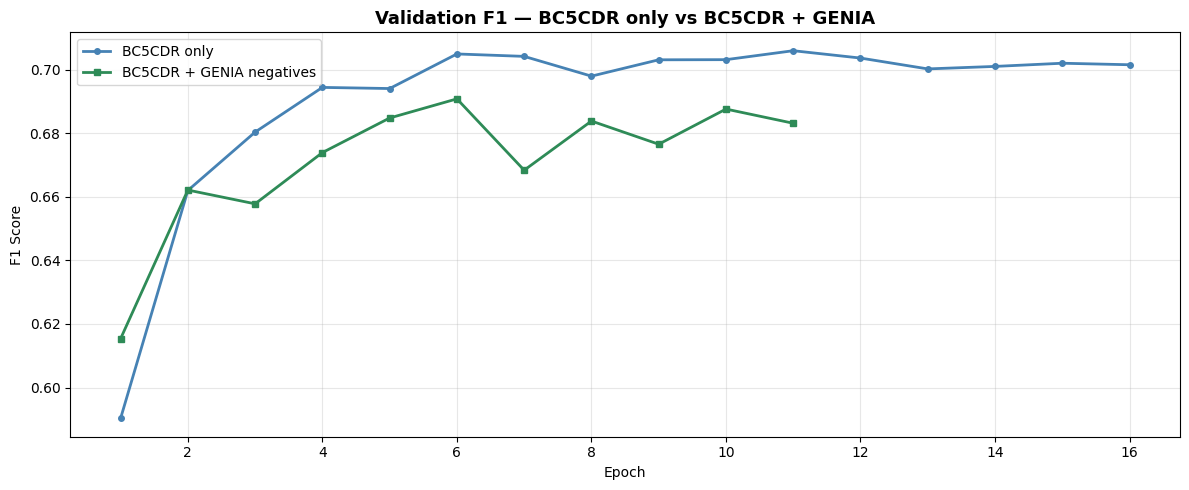

Saved: val_f1_comparison.png


In [14]:
# Plot 1 — Val F1 curves side by side
e1 = [h['epoch']  for h in history_base]
f1 = [h['val_f1'] for h in history_base]
e2 = [h['epoch']  for h in history_genia]
f2 = [h['val_f1'] for h in history_genia]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(e1, f1, color='steelblue',  linewidth=2, marker='o', markersize=4, label='BC5CDR only')
ax.plot(e2, f2, color='seagreen',   linewidth=2, marker='s', markersize=4, label='BC5CDR + GENIA negatives')
ax.set_title('Validation F1 — BC5CDR only vs BC5CDR + GENIA', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('F1 Score')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('val_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: val_f1_comparison.png')

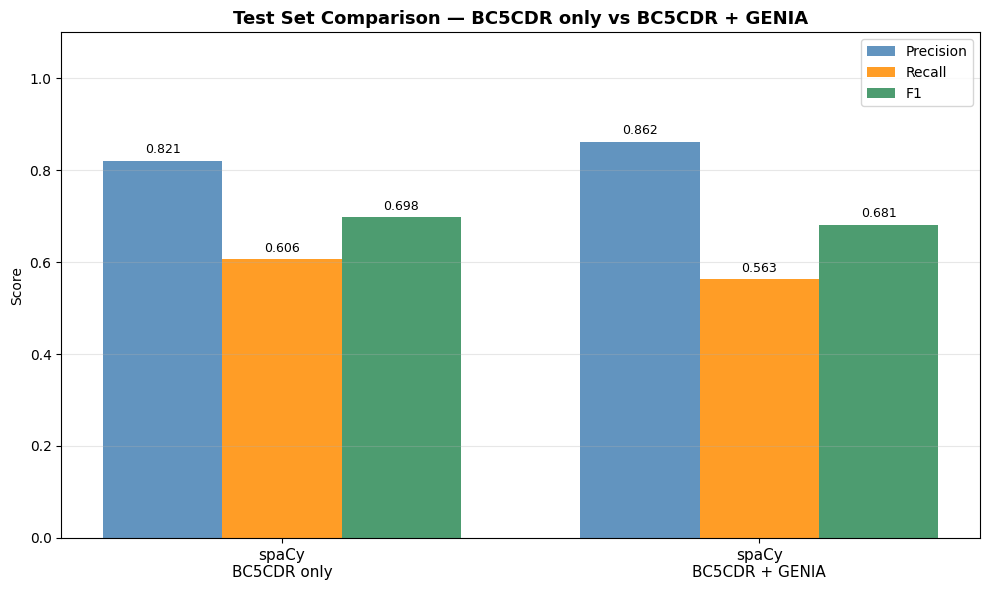

Saved: test_comparison.png


In [15]:
# Plot 2 — Test scores bar chart comparison
models    = ['spaCy\nBC5CDR only', 'spaCy\nBC5CDR + GENIA']
test_f1s  = [test_scores_base.get('ents_f', 0), test_scores_genia.get('ents_f', 0)]
test_ps   = [test_scores_base.get('ents_p', 0), test_scores_genia.get('ents_p', 0)]
test_rs   = [test_scores_base.get('ents_r', 0), test_scores_genia.get('ents_r', 0)]

x = np.arange(len(models)); width = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width, test_ps,  width, label='Precision', color='steelblue',  alpha=0.85)
b2 = ax.bar(x,         test_rs,  width, label='Recall',    color='darkorange', alpha=0.85)
b3 = ax.bar(x + width, test_f1s, width, label='F1',        color='seagreen',   alpha=0.85)
for bar in [*b1, *b2, *b3]:
    h = bar.get_height()
    if h > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9)
ax.set_title('Test Set Comparison — BC5CDR only vs BC5CDR + GENIA', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.1); ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('test_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: test_comparison.png')

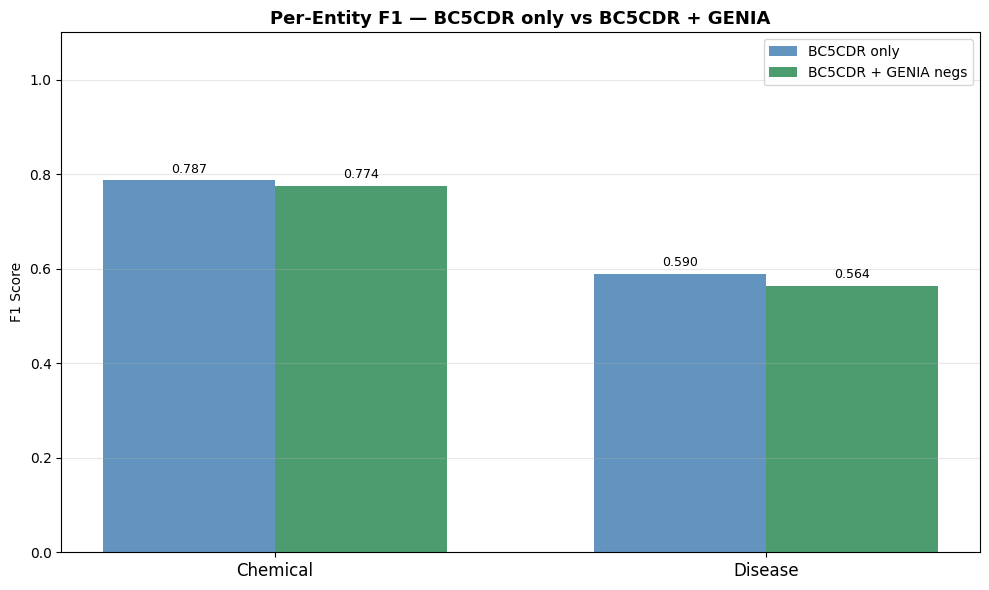

Saved: per_entity_comparison.png


In [16]:
# Plot 3 — Per-entity comparison (Chemical and Disease)
per_base  = json.load(open(SAVE_DIR_BASE  + '/val_scores.json')).get('ents_per_type', {})
per_genia = json.load(open(SAVE_DIR_GENIA + '/val_scores.json')).get('ents_per_type', {})

ent_types = list(per_base.keys())
x = np.arange(len(ent_types)); width = 0.35

f1_base  = [per_base[e].get('f', 0)  for e in ent_types]
f1_genia = [per_genia.get(e, {}).get('f', 0) for e in ent_types]

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width/2, f1_base,  width, label='BC5CDR only',         color='steelblue',  alpha=0.85)
b2 = ax.bar(x + width/2, f1_genia, width, label='BC5CDR + GENIA negs', color='seagreen',   alpha=0.85)
for bar in [*b1, *b2]:
    h = bar.get_height()
    if h > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9)
ax.set_title('Per-Entity F1 — BC5CDR only vs BC5CDR + GENIA', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(ent_types, fontsize=12)
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1.1); ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_entity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_entity_comparison.png')

Getting token predictions (may take a few minutes)...


/usr/local/lib/python3.12/dist-packages/spacy/pipeline/attributeruler.py:138: UserWarning: [W036] The component 'matcher' does not have any patterns defined.
  matches = self.matcher(doc, allow_missing=True, as_spans=False)
/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:187: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


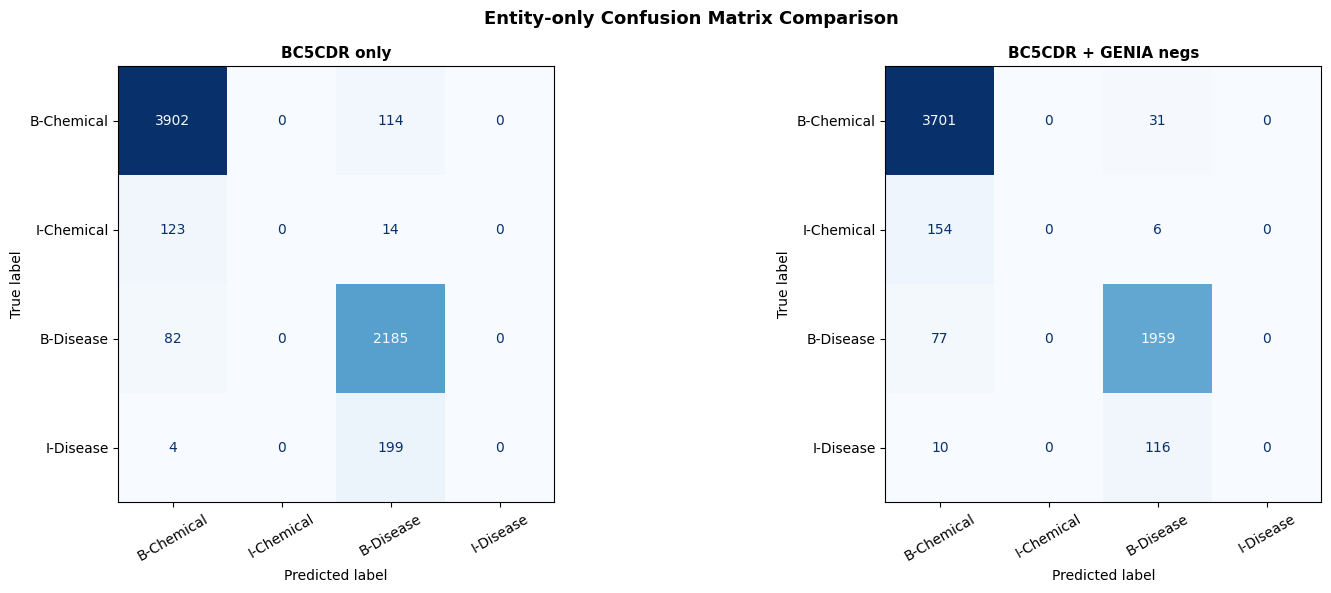

Saved: confusion_comparison.png


In [17]:
# Plot 4 — Confusion matrices side by side
print('Getting token predictions (may take a few minutes)...')
all_trues_base,  all_preds_base  = get_token_preds_trues(test_examples_base,  nlp_base_model)
all_trues_genia, all_preds_genia = get_token_preds_trues(test_examples_genia, nlp_genia_model)

labels_no_O = ['B-Chemical', 'I-Chemical', 'B-Disease', 'I-Disease']

def plot_cm(trues, preds, labels, title, ax):
    flat_true = [t for t in trues if t != 'O']
    flat_pred = [p for t, p in zip(trues, preds) if t != 'O']
    cm = confusion_matrix(flat_true, flat_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
    ax.set_title(title, fontsize=11, fontweight='bold')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plot_cm(all_trues_base,  all_preds_base,  labels_no_O, 'BC5CDR only',         ax1)
plot_cm(all_trues_genia, all_preds_genia, labels_no_O, 'BC5CDR + GENIA negs', ax2)
plt.suptitle('Entity-only Confusion Matrix Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_comparison.png')

In [18]:
# Plot 5 — Error examples: where base failed but genia succeeded
print('=' * 80)
print('Examples where BC5CDR+GENIA model succeeded but BC5CDR-only model failed')
print('=' * 80)

shown = 0
for ex in test_examples_base:
    gold_doc  = ex.reference
    pred_base = nlp_base_model(gold_doc.text)
    pred_genia = nlp_genia_model(gold_doc.text)

    gold_ents  = {(e.start_char, e.end_char): e.label_ for e in gold_doc.ents}
    base_ents  = {(e.start_char, e.end_char): e.label_ for e in pred_base.ents}
    genia_ents = {(e.start_char, e.end_char): e.label_ for e in pred_genia.ents}

    base_correct  = (base_ents  == gold_ents)
    genia_correct = (genia_ents == gold_ents)

    if (not base_correct) and genia_correct:
        print(f'\nExample {shown+1}')
        print(f'Text : {gold_doc.text[:120]}')
        print(f'Gold : {[(gold_doc.text[s:e], l) for (s,e),l in gold_ents.items()]}')
        print(f'Base : {[(pred_base.text[s:e], l) for (s,e),l in base_ents.items()]}')
        print(f'GENIA: {[(pred_genia.text[s:e], l) for (s,e),l in genia_ents.items()]}')
        shown += 1
        if shown >= 10: break

if shown == 0:
    print('No examples found where GENIA helped but base failed.')

Examples where BC5CDR+GENIA model succeeded but BC5CDR-only model failed

Example 1
Text : Moderate to high dose corticosteroid use is recognized as a major risk factor for SRC .
Gold : [('corticosteroid', 'Chemical'), ('SRC', 'Disease')]
Base : [('SRC', 'Disease')]
GENIA: [('corticosteroid', 'Chemical'), ('SRC', 'Disease')]


/usr/local/lib/python3.12/dist-packages/spacy/pipeline/attributeruler.py:138: UserWarning: [W036] The component 'matcher' does not have any patterns defined.
  matches = self.matcher(doc, allow_missing=True, as_spans=False)
/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:187: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)



Example 2
Text : The function of P2X3 receptor and NK1 receptor antagonists on cyclophosphamide - induced cystitis in rats .
Gold : [('cyclophosphamide', 'Chemical'), ('cystitis', 'Disease')]
Base : [('P2X3', 'Chemical'), ('cyclophosphamide', 'Chemical'), ('cystitis', 'Disease')]
GENIA: [('cyclophosphamide', 'Chemical'), ('cystitis', 'Disease')]

Example 3
Text : Immunofluorescence was used to detect the expression of P2X3 and NK1 receptors in bladder .
Gold : []
Base : [('P2X3', 'Chemical')]
GENIA: []

Example 4
Text : Performance status ( PS ) and initial lenalidomide dose predicted for treatment discontinuation .
Gold : [('lenalidomide', 'Chemical')]
Base : [('PS', 'Chemical'), ('lenalidomide', 'Chemical')]
GENIA: [('lenalidomide', 'Chemical')]

Example 5
Text : Cytogenetic markers for sister chromatid exchanges ( SCEs ), proliferation rate index ( PRI ) and Mitotic Index were rec
Gold : []
Base : [('SCEs', 'Disease')]
GENIA: []

Example 6
Text : Mesna significantly reduces IFO ' s

In [19]:
# Final summary table
print('\n' + '=' * 60)
print('FINAL COMPARISON — spaCy NER on BC5CDR Test Set')
print('=' * 60)
print(f'{"Model":<30} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 60)
print(f'{"spaCy BC5CDR only":<30} '
      f'{test_scores_base.get("ents_p",0):>10.4f} '
      f'{test_scores_base.get("ents_r",0):>10.4f} '
      f'{test_scores_base.get("ents_f",0):>10.4f}')
print(f'{"spaCy BC5CDR + GENIA negs":<30} '
      f'{test_scores_genia.get("ents_p",0):>10.4f} '
      f'{test_scores_genia.get("ents_r",0):>10.4f} '
      f'{test_scores_genia.get("ents_f",0):>10.4f}')
print('-' * 60)
diff = test_scores_genia.get('ents_f',0) - test_scores_base.get('ents_f',0)
direction = '↑ improved' if diff > 0 else '↓ decreased'
print(f'\nF1 difference: {diff:+.4f} ({direction})')
print('\nConclusion:')
if diff > 0:
    print('Adding GENIA as negative samples HELPED — model learned to ignore biomedical noise.')
elif diff < 0:
    print('Adding GENIA as negative samples HURT — too many O labels confused the model.')
else:
    print('Adding GENIA as negative samples made NO difference.')


FINAL COMPARISON — spaCy NER on BC5CDR Test Set
Model                           Precision     Recall         F1
------------------------------------------------------------
spaCy BC5CDR only                  0.8210     0.6065     0.6976
spaCy BC5CDR + GENIA negs          0.8616     0.5629     0.6809
------------------------------------------------------------

F1 difference: -0.0167 (↓ decreased)

Conclusion:
Adding GENIA as negative samples HURT — too many O labels confused the model.


In [21]:
import os

# Save base model (BC5CDR only)
os.makedirs('/kaggle/working/models/spacy/bc5cdr_only', exist_ok=True)
nlp_base_model.to_disk('/kaggle/working/models/spacy/bc5cdr_only')
print("✅ Base model saved to /kaggle/working/models/spacy/bc5cdr_only")

# Save GENIA model (BC5CDR + GENIA)
os.makedirs('/kaggle/working/models/spacy/bc5cdr_genia', exist_ok=True)
nlp_genia_model.to_disk('/kaggle/working/models/spacy/bc5cdr_genia')
print("✅ GENIA model saved to /kaggle/working/models/spacy/bc5cdr_genia")

✅ spacy_ner_ckpt.zip created
✅ spacy_ner_genia_ckpt.zip created


In [22]:
import shutil
shutil.make_archive('/kaggle/working/spacy_ner_ckpt', 'zip', 
                    '/kaggle/working/models/spacy/bc5cdr_only/model-best')
shutil.make_archive('/kaggle/working/spacy_ner_genia_ckpt', 'zip', 
                    '/kaggle/working/models/spacy/bc5cdr_genia/model-best')
print('✅ done')

✅ done


In [23]:
import os
files = os.listdir('/kaggle/working')
for f in files:
    print(f)

spacy_ner_genia_ckpt.zip
confusion_comparison.png
models
state.db
test_comparison.png
.virtual_documents
per_entity_comparison.png
spacy_ner_ckpt.zip
val_f1_comparison.png
